In [3]:
!pip install segmentation-models-pytorch
!pip install albumentations
!pip install rasterio

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [4]:
!pip install segmentation-models-pytorch albumentations rasterio

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [6]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [9]:
!pip install matplotlib segmentation-models-pytorch albumentations rasterio opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [11]:
import sys
!{sys.executable} -m pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ----------------------------- -------- 41.0/52.8 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 340.7 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------- ------------ 81.9/119.8 kB 2.2 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.2/8.1 MB 5.0 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.1 MB 5.1 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/8.1 MB 6.1 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/8.1 MB 5.3 MB/s eta 0:00:02
   ------ ---------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
IMAGE_DIR = r"D:\PB_training_dataSet_shp_file\Dataset to train\original"
LABEL_DIR = r"D:\PB_training_dataSet_shp_file\Dataset to train\labels"

In [7]:
import os

image_paths = []
label_paths = []

for file in os.listdir(IMAGE_DIR):

    if file.endswith(".tif"):

        img_path = os.path.join(IMAGE_DIR, file)
        mask_path = os.path.join(LABEL_DIR, file)

        if os.path.exists(mask_path):

            image_paths.append(img_path)
            label_paths.append(mask_path)

print("Total images:", len(image_paths))

Total images: 12


In [8]:
import cv2
import numpy as np

img = cv2.imread(image_paths[0])
mask = cv2.imread(label_paths[0],0)

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Classes:", np.unique(mask))

Image shape: (780, 1578, 3)
Mask shape: (780, 1578)
Classes: [0 1 2 3 4 5]


Dynamic Tile Function

In [9]:
import numpy as np

def random_tile(img, mask, size=512):

    h, w = img.shape[:2]

    x = np.random.randint(0, w-size)
    y = np.random.randint(0, h-size)

    img_tile = img[y:y+size, x:x+size]
    mask_tile = mask[y:y+size, x:x+size]

    return img_tile, mask_tile

Data Augmentation

In [10]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

Dataset Class

In [11]:
import cv2
import torch
from torch.utils.data import Dataset

class SatelliteDataset(Dataset):

    def __init__(self, image_paths, label_paths):

        self.image_paths = image_paths
        self.label_paths = label_paths

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.image_paths[idx])
        mask = cv2.imread(self.label_paths[idx],0)

        img, mask = random_tile(img, mask)

        augmented = transform(image=img, mask=mask)

        img = augmented["image"]
        mask = augmented["mask"]

        img = img / 255.0
        img = np.transpose(img,(2,0,1))

        return torch.tensor(img).float(), torch.tensor(mask).long()

DataLoader

In [27]:
from torch.utils.data import DataLoader

dataset = SatelliteDataset(image_paths, label_paths)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

In [28]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=6
)

In [29]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print("Using device:", device)

Using device: cpu


In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp

dice_loss = smp.losses.DiceLoss(mode="multiclass")
ce_loss = nn.CrossEntropyLoss()

def loss_fn(pred, target):
    return dice_loss(pred,target) + ce_loss(pred,target)

In [31]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001
)

In [32]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [34]:
from tqdm import tqdm

In [35]:
from tqdm import tqdm
import time

epochs = 80

for epoch in range(epochs):

    start = time.time()   # start timing for this epoch

    model.train()
    total_loss = 0

    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

    for imgs, masks in progress_bar:

        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    epoch_time = time.time() - start

    print(f"Epoch {epoch+1}/{epochs} Total Loss: {total_loss:.4f}")
    print(f"Epoch time: {epoch_time:.2f} seconds")

Epoch 1/80: 100%|██████████| 6/6 [00:55<00:00,  9.25s/it, loss=2.33]


Epoch 1/80 Total Loss: 14.4963
Epoch time: 55.50 seconds


Epoch 2/80: 100%|██████████| 6/6 [01:44<00:00, 17.35s/it, loss=2.29]


Epoch 2/80 Total Loss: 13.5587
Epoch time: 104.09 seconds


Epoch 3/80: 100%|██████████| 6/6 [01:29<00:00, 14.85s/it, loss=2.16]


...

Epoch 78/80 Total Loss: 5.8068
Epoch time: 33.70 seconds


Epoch 79/80: 100%|██████████| 6/6 [00:35<00:00,  5.88s/it, loss=1]    


Epoch 79/80 Total Loss: 6.4309
Epoch time: 35.28 seconds


Epoch 80/80: 100%|██████████| 6/6 [00:35<00:00,  5.91s/it, loss=0.987]

Epoch 80/80 Total Loss: 6.1101
Epoch time: 35.48 seconds


In [36]:
torch.save(model.state_dict(), "feature_extraction_unet_resnet50.pth")

In [38]:
import torch
import cv2
import numpy as np

model.eval()

total_pixels = 0
correct_pixels = 0

with torch.no_grad():

    for img_path, mask_path in zip(image_paths, label_paths):

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path,0)

        img = img/255.0
        img = np.transpose(img,(2,0,1))

        tensor = torch.tensor(img).unsqueeze(0).float().to(device)

        pred = model(tensor)

        pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

        # 🔧 FIX: resize prediction to match mask
        pred_mask = cv2.resize(pred_mask, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_NEAREST)

        total_pixels += mask.size
        correct_pixels += (pred_mask == mask).sum()

accuracy = correct_pixels / total_pixels

print("Pixel Accuracy:", accuracy*100,"%")

Pixel Accuracy: 91.07066238064452 %


In [39]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

model.eval()

accuracies = []

with torch.no_grad():

    for img_path, mask_path in zip(image_paths, label_paths):

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path,0)

        img = img/255.0
        img = np.transpose(img,(2,0,1))

        tensor = torch.tensor(img).unsqueeze(0).float().to(device)

        pred = model(tensor)

        pred_mask = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

        # resize fix
        pred_mask = cv2.resize(pred_mask,(mask.shape[1],mask.shape[0]),interpolation=cv2.INTER_NEAREST)

        accuracy = (pred_mask == mask).sum() / mask.size

        accuracies.append(accuracy*100)

print("Average Accuracy:", np.mean(accuracies), "%")

Average Accuracy: 91.22206819049863 %


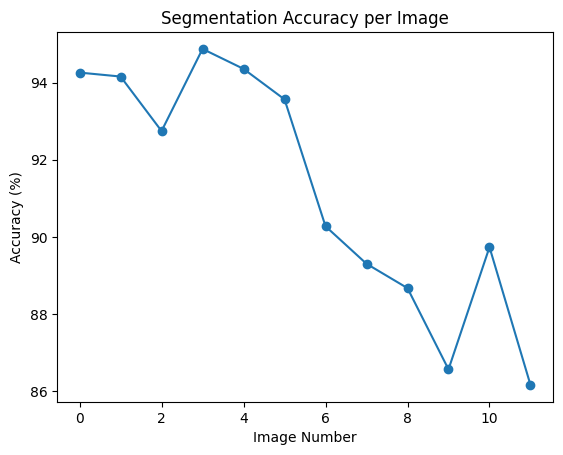

In [40]:
plt.figure()

plt.plot(accuracies, marker="o")

plt.xlabel("Image Number")
plt.ylabel("Accuracy (%)")
plt.title("Segmentation Accuracy per Image")

plt.show()